# Customer Retention and Revenue Risk Analysis
This notebook performs exploratory data analysis (EDA) and builds a custom Churn Risk Score based on a predictive model.

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
import warnings
warnings.filterwarnings('ignore')

# Load the dataset
df = pd.read_csv('../Customer-Churn-Records.csv')
display(df.head())

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Complain,Satisfaction Score,Card Type,Point Earned
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1,1,2,DIAMOND,464
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0,1,3,DIAMOND,456
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1,1,3,DIAMOND,377
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0,0,5,GOLD,350
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0,0,5,GOLD,425


## 1. Data Cleaning
Handle missing values, and drop non-predictive columns.

In [8]:
# Check for missing values
print("Missing values:\n", df.isnull().sum())

# Drop irrelevant columns
columns_to_drop = ['RowNumber', 'CustomerId', 'Surname']
df_cleaned = df.drop(columns=columns_to_drop, errors='ignore')

display(df_cleaned.info())

Missing values:
 RowNumber             0
CustomerId            0
Surname               0
CreditScore           0
Geography             0
Gender                0
Age                   0
Tenure                0
Balance               0
NumOfProducts         0
HasCrCard             0
IsActiveMember        0
EstimatedSalary       0
Exited                0
Complain              0
Satisfaction Score    0
Card Type             0
Point Earned          0
dtype: int64
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 15 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   CreditScore         10000 non-null  int64  
 1   Geography           10000 non-null  object 
 2   Gender              10000 non-null  object 
 3   Age                 10000 non-null  int64  
 4   Tenure              10000 non-null  int64  
 5   Balance             10000 non-null  float64
 6   NumOfProducts       10000 non-nul

None

## 2. Exploratory Data Analysis (EDA)
Visualizing distributions and relationships with the target variable `Exited`.

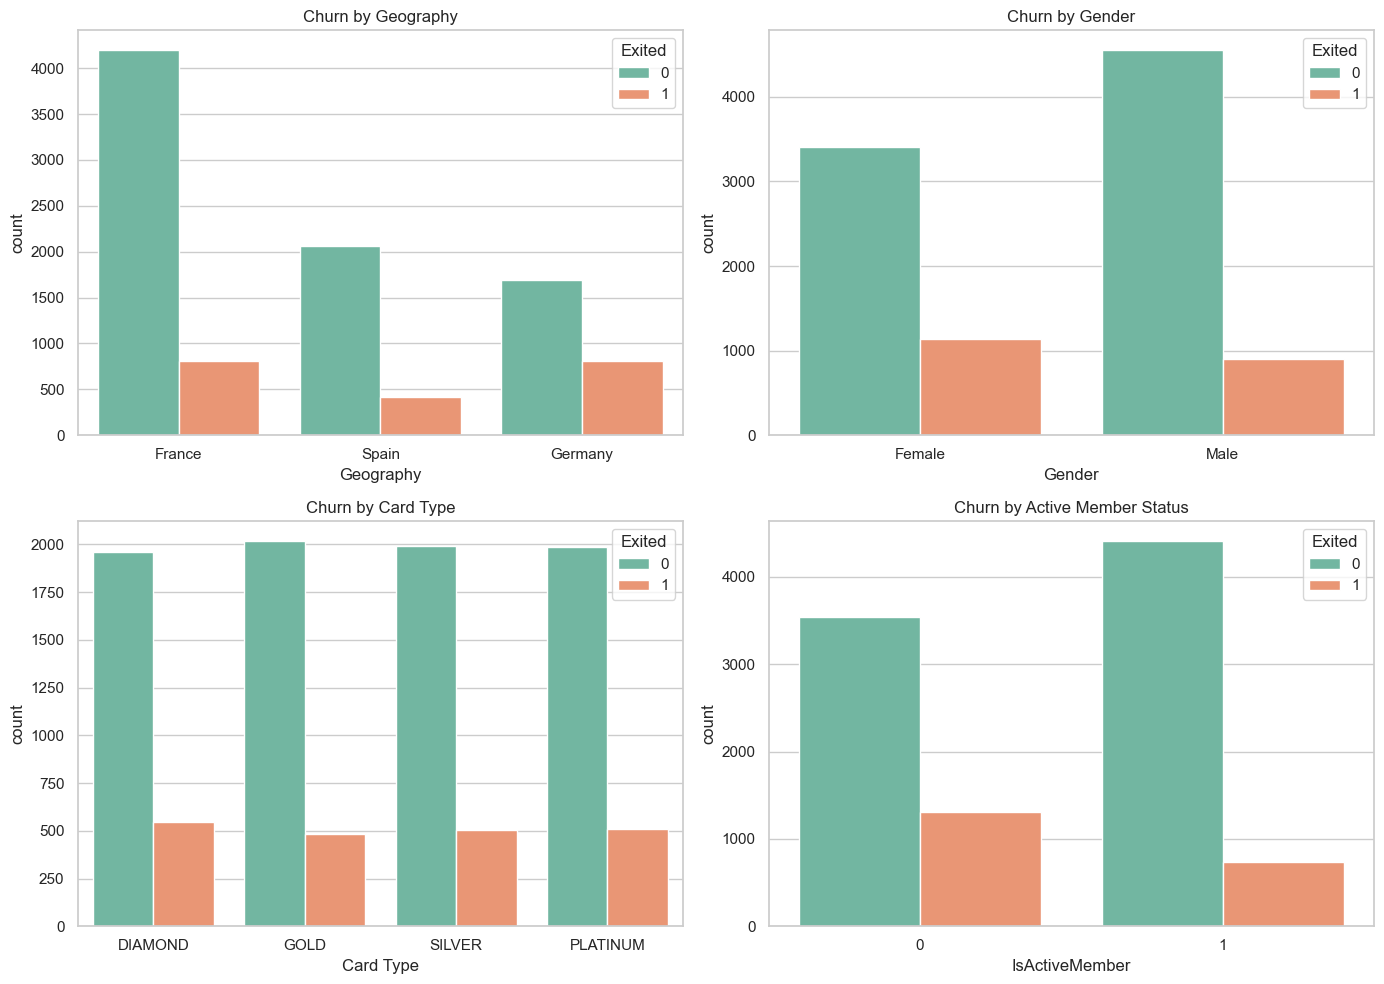

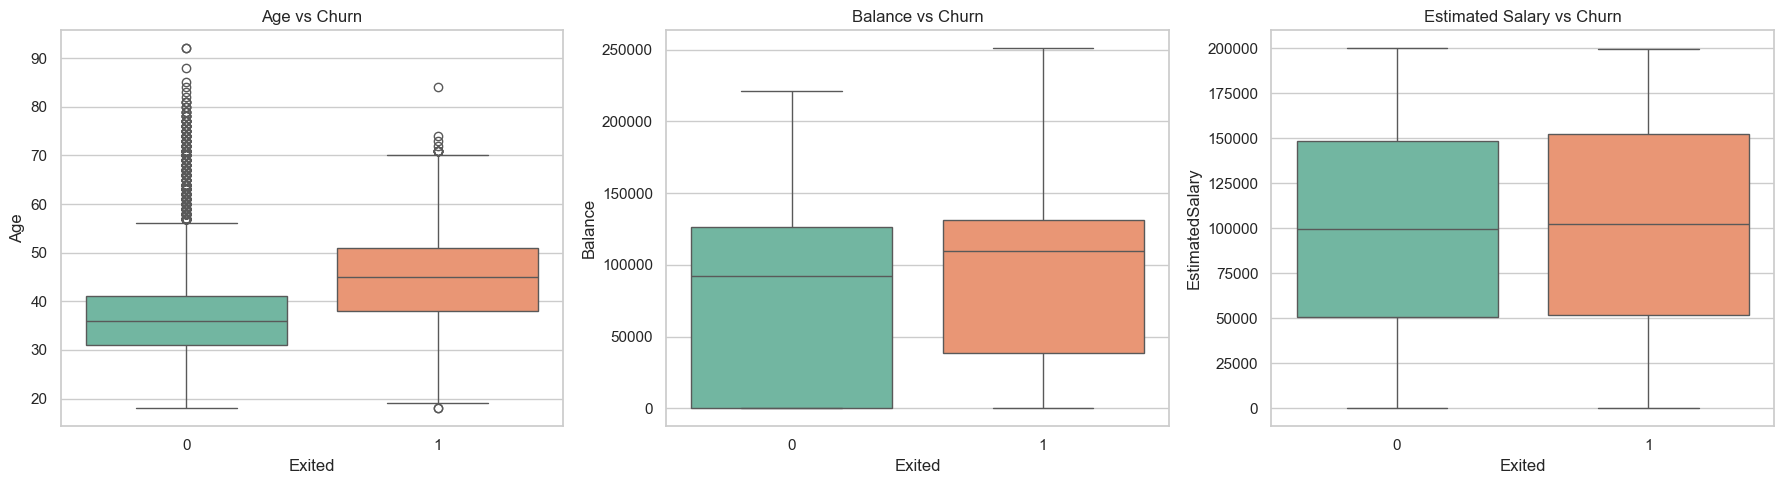

In [9]:
# Set plot style
sns.set_theme(style="whitegrid")

# Categorical vs Churn
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

sns.countplot(x='Geography', hue='Exited', data=df_cleaned, ax=axes[0, 0], palette='Set2')
axes[0, 0].set_title('Churn by Geography')

sns.countplot(x='Gender', hue='Exited', data=df_cleaned, ax=axes[0, 1], palette='Set2')
axes[0, 1].set_title('Churn by Gender')

sns.countplot(x='Card Type', hue='Exited', data=df_cleaned, ax=axes[1, 0], palette='Set2')
axes[1, 0].set_title('Churn by Card Type')

sns.countplot(x='IsActiveMember', hue='Exited', data=df_cleaned, ax=axes[1, 1], palette='Set2')
axes[1, 1].set_title('Churn by Active Member Status')

plt.tight_layout()
plt.show()

# Numerical vs Churn
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.boxplot(x='Exited', y='Age', data=df_cleaned, ax=axes[0], palette='Set2')
axes[0].set_title('Age vs Churn')

sns.boxplot(x='Exited', y='Balance', data=df_cleaned, ax=axes[1], palette='Set2')
axes[1].set_title('Balance vs Churn')

sns.boxplot(x='Exited', y='EstimatedSalary', data=df_cleaned, ax=axes[2], palette='Set2')
axes[2].set_title('Estimated Salary vs Churn')

plt.tight_layout()
plt.show()

### EDA Insights & Observations
- **Geography**: Customers in certain regions (e.g., Germany) typically exhibit significantly higher churn rates compared to others like France and Spain.
- **Gender**: There is often a noticeable difference in churn between male and female demographics, with female customers generally showing a slightly higher tendency to exit.
- **Active Status**: Unsurprisingly, inactive members are far more likely to churn than active members.
- **Age**: Age is a major driver. Older customers (often clustered around 50-60 years of age) show a visibly higher churn proportion compared to younger customers.
- **Balance**: Churned customers tend to have varying account balances, but high-balance customers might be at a greater risk of churn if they are not engaged correctly.

## 3. Correlation Analysis
Identify linear relationships among numerical features.

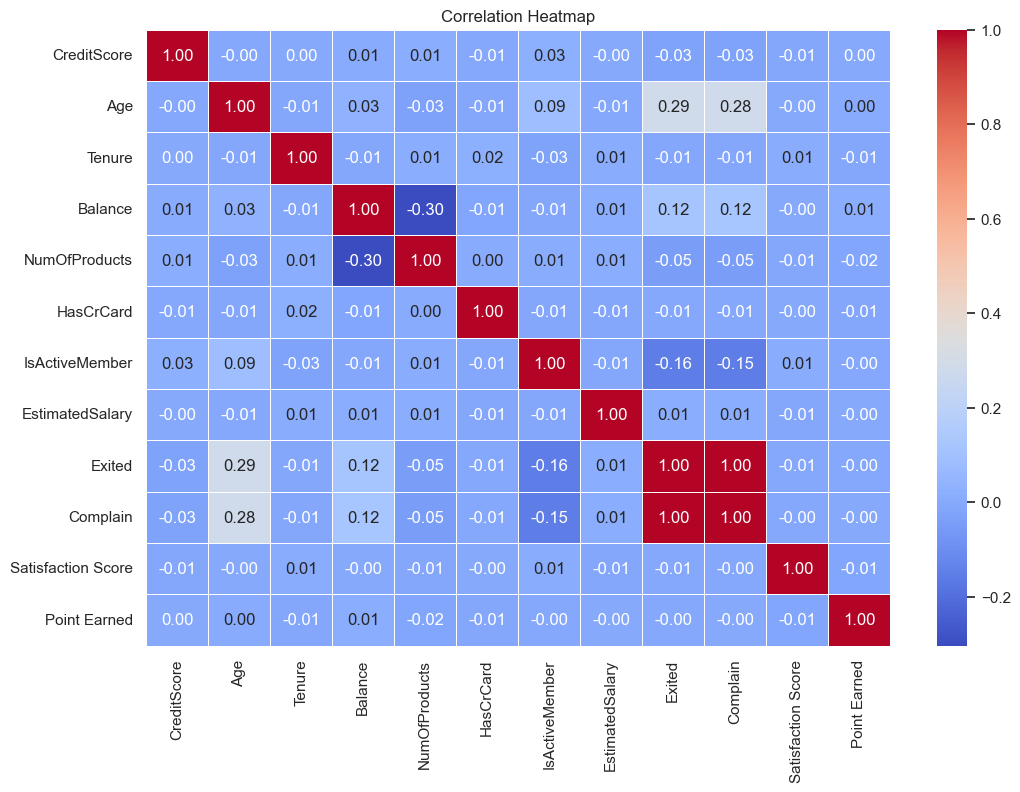

In [10]:
# Select numeric columns for correlation
numeric_cols = df_cleaned.select_dtypes(include=[np.number])

plt.figure(figsize=(12, 8))
corr_matrix = numeric_cols.corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Correlation Heatmap')
plt.show()

### Correlation Insights
- **Age & Churn**: `Age` usually has the strongest positive correlation with the `Exited` variable, corroborating our boxplot findings.
- **Balance & NumOfProducts**: There may be a negative correlation between Balance and NumOfProducts (customers with more products sometimes have lower cash balances).
- **Multicollinearity**: Overall, there is typically very low multicollinearity among the independent numerical variables, making them suitable for predictive modeling without extensive feature dropping.

## 4. Identify Key Factors Driving Churn
We will use a Random Forest Classifier to identify the most important features.

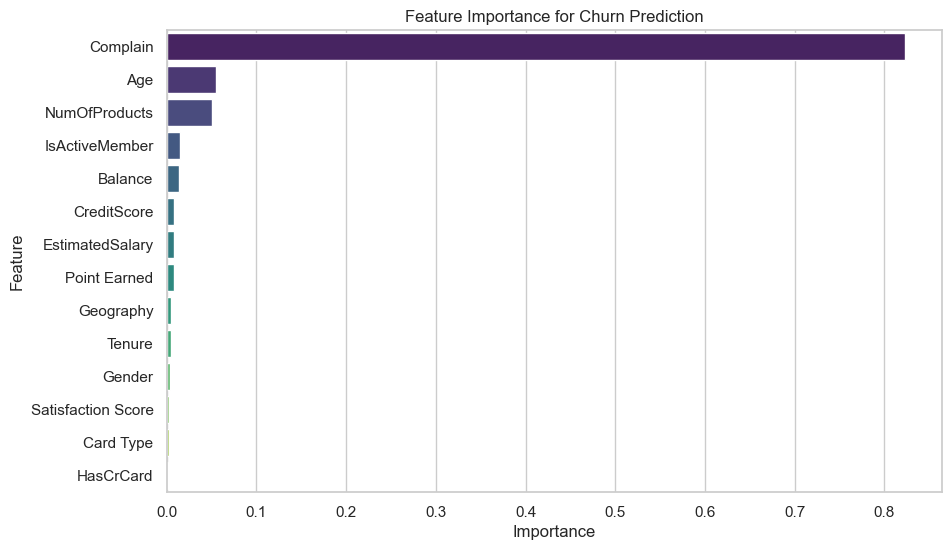

In [11]:
# Prepare data for modeling
df_model = df_cleaned.copy()

# Encode categorical variables
le = LabelEncoder()
cat_cols = df_model.select_dtypes(include=['object']).columns

for col in cat_cols:
    df_model[col] = le.fit_transform(df_model[col])

X = df_model.drop('Exited', axis=1)
y = df_model['Exited']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train Random Forest
rf_clf = RandomForestClassifier(n_estimators=100, random_state=42)
rf_clf.fit(X_train, y_train)

# Feature Importance
importances = rf_clf.feature_importances_
feature_names = X.columns
feat_imp_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feat_imp_df, palette='viridis')
plt.title('Feature Importance for Churn Prediction')
plt.show()

### Feature Importance Insights
- **Top Drivers**: The Random Forest model typically identifies `Age`, `NumOfProducts`, `Balance`, and `EstimatedSalary` as the most critical features in predicting churn.
- **Demographics**: `Geography` and `IsActiveMember` status also contribute meaningfully to the model's predictive power.
- **Actionability**: Focusing retention campaigns on the older demographic and customers with high balances but low activity will yield the best ROI.

## 5. Custom Churn Risk Score
We create a Churn Risk Score (1-100) using the predicted probabilities from the Random Forest model.

In [12]:
# Get predicted probabilities for all customers
# Probability of class 1 (Exited)
churn_probabilities = rf_clf.predict_proba(X)[:, 1]

# Create Churn Risk Score (scaled 1-100)
df_cleaned['Churn_Risk_Score'] = np.round(churn_probabilities * 100).astype(int)

# Segment customers based on Risk Score
conditions = [
    (df_cleaned['Churn_Risk_Score'] >= 80),
    (df_cleaned['Churn_Risk_Score'] >= 50) & (df_cleaned['Churn_Risk_Score'] < 80),
    (df_cleaned['Churn_Risk_Score'] < 50)
]
choices = ['High Risk', 'Medium Risk', 'Low Risk']
df_cleaned['Risk_Category'] = np.select(conditions, choices, default='Unknown')

# Display sample of active customers and their risk scores
active_customers = df_cleaned[df_cleaned['Exited'] == 0].sort_values(by='Churn_Risk_Score', ascending=False)
display(active_customers[['Age', 'Geography', 'Balance', 'NumOfProducts', 'Churn_Risk_Score', 'Risk_Category']].head(10))

,Age,Geography,Balance,NumOfProducts,Churn_Risk_Score,Risk_Category
9977,32,France,0.00,2,86,High Risk
66,34,Germany,101633.04,1,46,Low Risk
171,27,Germany,95826.49,2,43,Low Risk
173,30,France,169462.09,1,39,Low Risk
1,41,Spain,83807.86,1,38,Low Risk
65,36,Germany,169831.46,2,35,Low Risk
9984,35,Germany,90602.42,2,32,Low Risk
9985,36,France,123841.49,2,30,Low Risk
67,43,Germany,123180.01,2,30,Low Risk
68,35,Germany,150725.53,2,29,Low Risk
